### Business Understanding

Mobile network operators continuously seek to improve user experience by ensuring reliable coverage and high-quality service. Drive testing is a standard practice for measuring real-world signal strength, quality, and network performance parameters across geographic areas. However, conducting drive tests is costly, time-consuming, and logistically complex.

The goal of this project is to develop a machine learning model that can predict key radio network KPIs — namely RSRP (Reference Signal Received Power), RSRQ (Reference Signal Received Quality), and SNR (Signal-to-Noise Ratio) — based on other measured parameters such as location, speed, and cell attributes.

Accurate prediction of these KPIs enables network planners and engineers to simulate and analyze network performance without needing extensive field measurements. This supports:

- Faster planning of new sites or upgrades

- Optimized network tuning and parameter adjustment

- Proactive identification of coverage or quality gaps

- Cost reduction in drive testing operations

By leveraging predictive modeling, mobile operators can make data-driven decisions to enhance coverage, capacity, and quality of service, directly improving end-user experience and competitive positioning.

# 📑 Data Dictionary: Drive Test Prediction Dataset
# 📘 Drive Test Dataset - Data Dictionary

| Feature Name             | Description                                                                      | Unit                   | Category            |
|--------------------------|----------------------------------------------------------------------------------|------------------------|---------------------|
| **Latitude**             | Geographic coordinate (north–south position) of the UE                          | Degrees                | Location            |
| **Longitude**            | Geographic coordinate (east–west position) of the UE                            | Degrees                | Location            |
| **Distance_m**           | Distance between the UE and the serving cell                                    | Meters (m)             | Spatial Metric      |
| **PathLoss_dB**          | Path loss between UE and cell; signal attenuation during transmission           | Decibels (dB)          | RF Metric           |
| **CellID**               | Identifier of the serving cell                                                  | Integer                | Network Identifier  |
| **RSRP_dBm**             | Reference Signal Received Power – signal strength from a single antenna        | dBm                    | Signal Quality      |
| **RSRQ_dB**              | Reference Signal Received Quality – quality of signal considering interference | dB                     | Signal Quality      |
| **SINR_dB**              | Signal-to-Interference-plus-Noise Ratio – signal quality vs noise              | dB                     | Signal Quality      |
| **Throughput_Mbps**      | Actual data rate received by the UE                                            | Mbps                   | Performance         |
| **CQI**                  | Channel Quality Indicator – estimation of current channel quality              | Integer (0–15)         | Channel Metric      |
| **MCS**                  | Modulation and Coding Scheme index used for transmission                       | Integer                | Physical Layer      |
| **BLER**                 | Block Error Rate – error ratio in received data blocks                         | Proportion (0–1)       | Performance         |
| **UE_TxPower_dBm**       | Transmission power of the user equipment (UE)                                  | dBm                    | UE RF Metric        |
| **RSSI_dBm**             | Received Signal Strength Indicator – total received power (signal + noise)     | dBm                    | Signal Strength     |
| **CellAntennaGain_dBi**  | Antenna gain of the base station                                               | dBi                    | Antenna Property    |
| **CellHeight_m**         | Height of the cell tower                                                       | Meters (m)             | Infrastructure      |
| **UEHeight_m**           | Height of the user device from the ground                                      | Meters (m)             | Infrastructure      |
| **UESpeed_kmh**          | Speed of the user equipment (mobile device)                                    | Kilometers per hour    | Mobility            |





### Data Understanding

In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import keras
import tensorflow as tf
from sklearn.preprocessing import RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error,mean_squared_error
from tensorflow.keras import layers, models, callbacks
from tensorflow import keras
import joblib

# Utility libraries
import warnings
warnings.filterwarnings(action="ignore")

print("import all libraries")

import all libraries


In [2]:
# Load the dataset
df = pd.read_csv("../data/ten_drivetest_data_latlon.csv")

# read first five rows
df.head()


,Latitude,Longitude,Distance_m,PathLoss_dB,CellID,RSRP_dBm,RSRQ_dB,SINR_dB,Throughput_Mbps,CQI,MCS,BLER,UE_TxPower_dBm,RSSI_dBm,CellAntennaGain_dBi,CellHeight_m,UEHeight_m,UESpeed_kmh
0,40.761023,-73.976731,117.745158,80.305019,5,-21.200108,169.798978386363+13.6437635384184i,173.171611,1150.527275,15,27,3.014758e-09,-59.570839,-124.247888,15.363650,32.912291,1.578404,35.006782
1,40.748257,-73.988530,780.293211,96.731315,3,-35.402599,172.025949244367+13.6437635384184i,153.424786,1019.332191,15,27,2.171932e-08,-43.144543,-132.906047,16.664885,35.247564,1.660524,20.351469
2,40.752382,-73.968726,254.393630,86.996283,1,-27.378540,170.909700672279+13.6437635384184i,168.694687,1120.783236,15,27,4.717184e-09,-52.879575,-132.127831,15.041169,31.834045,1.789815,18.864764
3,40.754388,-73.987464,1059.720014,99.389981,5,-39.973001,172.553265292561+13.6437635384184i,140.686947,934.703771,15,27,7.763249e-08,-40.485877,-129.309011,15.363650,32.912291,1.685947,40.281879
4,40.756813,-73.994663,939.036749,98.339810,3,-36.758789,172.189209665494+13.6437635384184i,156.420352,1039.234307,15,27,1.609720e-08,-41.536048,-138.613992,16.664885,35.247564,1.885629,34.815708


In [3]:
# Load the last 5 rows
df.tail()

,Latitude,Longitude,Distance_m,PathLoss_dB,CellID,RSRP_dBm,RSRQ_dB,SINR_dB,Throughput_Mbps,CQI,MCS,BLER,UE_TxPower_dBm,RSSI_dBm,CellAntennaGain_dBi,CellHeight_m,UEHeight_m,UESpeed_kmh
199995,40.756964,-73.970811,286.936453,88.041873,1,-28.237791,171.043904960487+13.6437635384184i,161.466728,1072.761713,15,27,9.718273e-09,-51.833986,-126.618373,15.041169,31.834045,1.923776,57.208642
199996,40.766762,-73.997982,1375.845460,101.657551,2,-40.030530,172.559511154502+13.6437635384184i,156.536104,1040.003348,15,27,1.591195e-08,-38.218307,-145.273227,16.939820,33.042422,1.621588,31.248034
199997,40.766798,-73.984720,363.727998,90.101693,2,-29.419366,171.221930839789+13.6437635384184i,173.399536,1152.041576,15,27,2.946822e-09,-49.774165,-140.914330,16.939820,33.042422,1.662731,11.930274
199998,40.753666,-73.974488,439.754875,91.750371,1,-33.251505,171.753710779332+13.6437635384184i,142.345423,945.722459,15,27,6.576833e-08,-48.125487,-117.524495,15.041169,31.834045,1.500673,41.262722
199999,40.753315,-73.990597,792.811272,96.869554,3,-35.468939,172.034079757499+13.6437635384184i,153.950461,1022.824700,15,27,2.060708e-08,-43.006304,-133.564402,16.664885,35.247564,1.607980,34.417991


In [4]:
# check the shape of the dataset
df.shape

(200000, 18)

In [5]:
df.columns

Index(['Latitude', 'Longitude', 'Distance_m', 'PathLoss_dB', 'CellID',
       'RSRP_dBm', 'RSRQ_dB', 'SINR_dB', 'Throughput_Mbps', 'CQI', 'MCS',
       'BLER', 'UE_TxPower_dBm', 'RSSI_dBm', 'CellAntennaGain_dBi',
       'CellHeight_m', 'UEHeight_m', 'UESpeed_kmh'],
      dtype='object')

In [6]:
# Read information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Latitude             200000 non-null  float64
 1   Longitude            200000 non-null  float64
 2   Distance_m           200000 non-null  float64
 3   PathLoss_dB          200000 non-null  float64
 4   CellID               200000 non-null  int64  
 5   RSRP_dBm             200000 non-null  float64
 6   RSRQ_dB              200000 non-null  object 
 7   SINR_dB              200000 non-null  float64
 8   Throughput_Mbps      200000 non-null  float64
 9   CQI                  200000 non-null  int64  
 10  MCS                  200000 non-null  int64  
 11  BLER                 200000 non-null  float64
 12  UE_TxPower_dBm       200000 non-null  float64
 13  RSSI_dBm             200000 non-null  float64
 14  CellAntennaGain_dBi  200000 non-null  float64
 15  CellHeight_m     

In [7]:
# Perform descriptive statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,200000.0,4.075801e+01,7.797702e-03,4.074449e+01,4.075125e+01,4.075803e+01,4.076475e+01,40.771513
Longitude,200000.0,-7.398551e+01,1.030173e-02,-7.400334e+01,-7.399443e+01,-7.398552e+01,-7.397658e+01,-73.967660
Distance_m,200000.0,7.133357e+02,3.857495e+02,8.741865e-01,4.133464e+02,6.717785e+02,9.631369e+02,1962.299549
PathLoss_dB,200000.0,9.437640e+01,5.796907e+00,3.888616e+01,9.121244e+01,9.543068e+01,9.855992e+01,104.741464
CellID,200000.0,2.960520e+00,1.232383e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00,5.000000
RSRP_dBm,200000.0,-3.413440e+01,5.629400e+00,-4.467915e+01,-3.821433e+01,-3.516550e+01,-3.113679e+01,21.380215
SINR_dB,200000.0,1.568840e+02,1.146275e+01,1.067489e+02,1.490968e+02,1.566798e+02,1.644044e+02,217.904112
Throughput_Mbps,200000.0,1.042315e+03,7.615688e+01,7.092224e+02,9.905776e+02,1.040958e+03,1.092279e+03,1447.723586
CQI,200000.0,1.500000e+01,0.000000e+00,1.500000e+01,1.500000e+01,1.500000e+01,1.500000e+01,15.000000
MCS,200000.0,2.700000e+01,0.000000e+00,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,27.000000


In [8]:
# Convert RSRQ_db from complex number to real number
df["RSRQ_dB"] = df["RSRQ_dB"].apply(lambda x: float(str(x).split("+")[0]) if "+" in str(x) else float(x))

# load head of dataset
df.head()

,Latitude,Longitude,Distance_m,PathLoss_dB,CellID,RSRP_dBm,RSRQ_dB,SINR_dB,Throughput_Mbps,CQI,MCS,BLER,UE_TxPower_dBm,RSSI_dBm,CellAntennaGain_dBi,CellHeight_m,UEHeight_m,UESpeed_kmh
0,40.761023,-73.976731,117.745158,80.305019,5,-21.200108,169.798978,173.171611,1150.527275,15,27,3.014758e-09,-59.570839,-124.247888,15.363650,32.912291,1.578404,35.006782
1,40.748257,-73.988530,780.293211,96.731315,3,-35.402599,172.025949,153.424786,1019.332191,15,27,2.171932e-08,-43.144543,-132.906047,16.664885,35.247564,1.660524,20.351469
2,40.752382,-73.968726,254.393630,86.996283,1,-27.378540,170.909701,168.694687,1120.783236,15,27,4.717184e-09,-52.879575,-132.127831,15.041169,31.834045,1.789815,18.864764
3,40.754388,-73.987464,1059.720014,99.389981,5,-39.973001,172.553265,140.686947,934.703771,15,27,7.763249e-08,-40.485877,-129.309011,15.363650,32.912291,1.685947,40.281879
4,40.756813,-73.994663,939.036749,98.339810,3,-36.758789,172.189210,156.420352,1039.234307,15,27,1.609720e-08,-41.536048,-138.613992,16.664885,35.247564,1.885629,34.815708


In [9]:
# check info about the modified data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Latitude             200000 non-null  float64
 1   Longitude            200000 non-null  float64
 2   Distance_m           200000 non-null  float64
 3   PathLoss_dB          200000 non-null  float64
 4   CellID               200000 non-null  int64  
 5   RSRP_dBm             200000 non-null  float64
 6   RSRQ_dB              200000 non-null  float64
 7   SINR_dB              200000 non-null  float64
 8   Throughput_Mbps      200000 non-null  float64
 9   CQI                  200000 non-null  int64  
 10  MCS                  200000 non-null  int64  
 11  BLER                 200000 non-null  float64
 12  UE_TxPower_dBm       200000 non-null  float64
 13  RSSI_dBm             200000 non-null  float64
 14  CellAntennaGain_dBi  200000 non-null  float64
 15  CellHeight_m     

In [10]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

#### Univariate analysis

In [11]:
first_batch_columns = ['Longitude', 'Latitude', 'Distance_m', 'PathLoss_dB', 'CellID', 'RSRP_dBm', 'SINR_dB',
       'Throughput_Mbps','RSRQ_dB']

second_batch_columns = ['CQI', 'MCS', 'BLER', 'UE_TxPower_dBm', 'RSSI_dBm',
       'CellAntennaGain_dBi', 'CellHeight_m', 'UEHeight_m','UESpeed_kmh' ]

<Figure size 1500x1000 with 0 Axes>

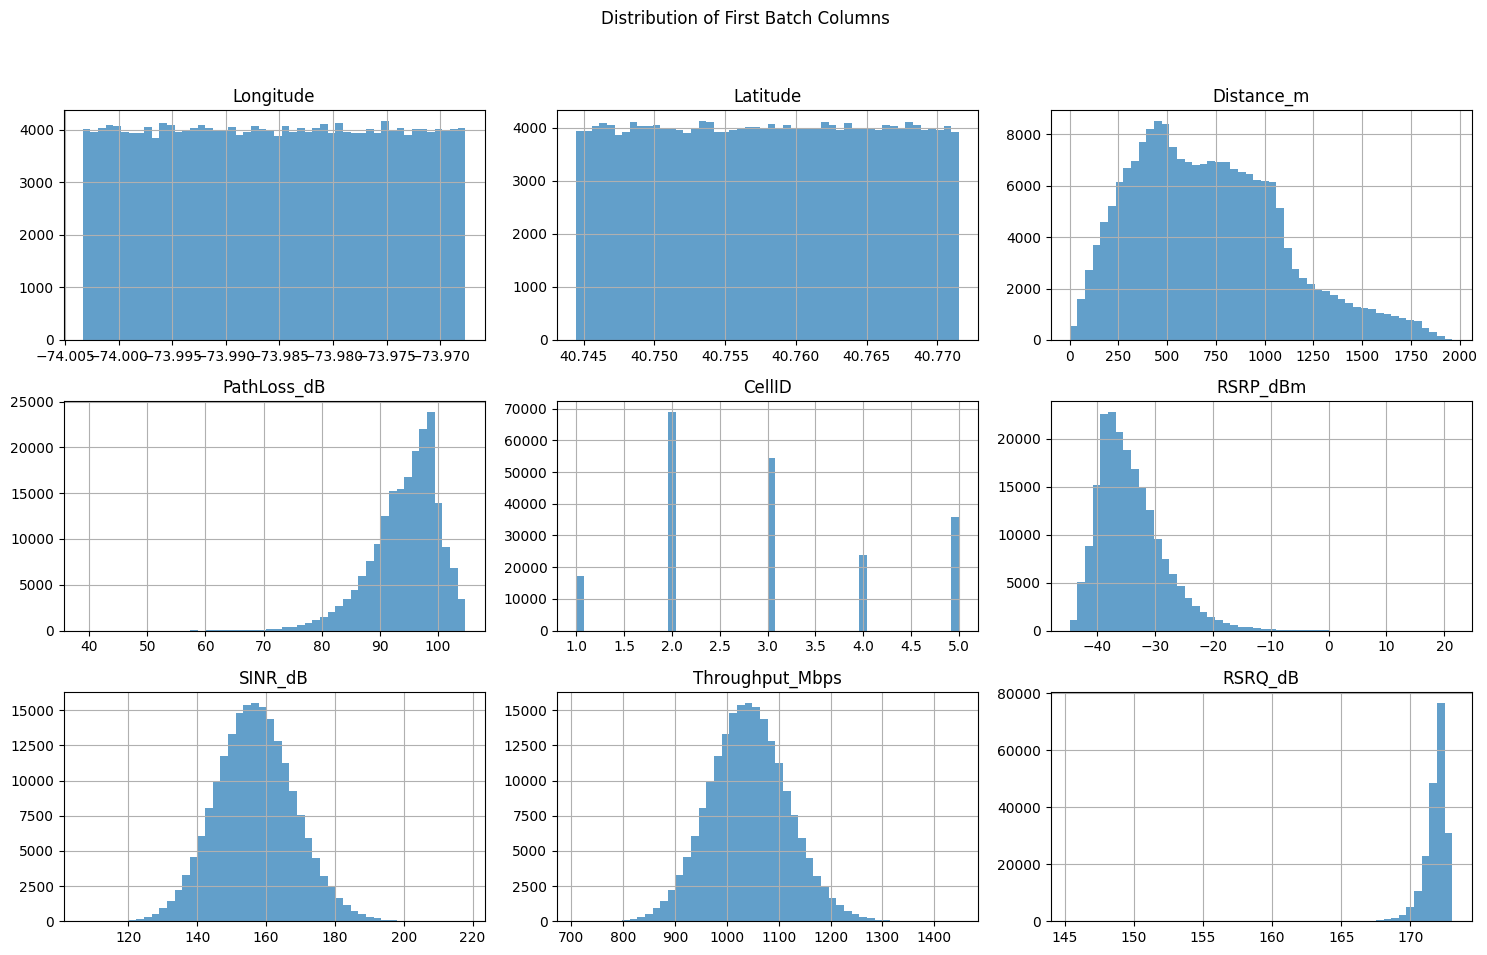

In [12]:
# Plotting the distribution of the first batch of columns
plt.figure(figsize=(15, 10))
df[first_batch_columns].hist(bins=50, figsize=(15, 10), layout=(3, 3), alpha=0.7)
plt.suptitle('Distribution of First Batch Columns') 
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

<Figure size 1500x1000 with 0 Axes>

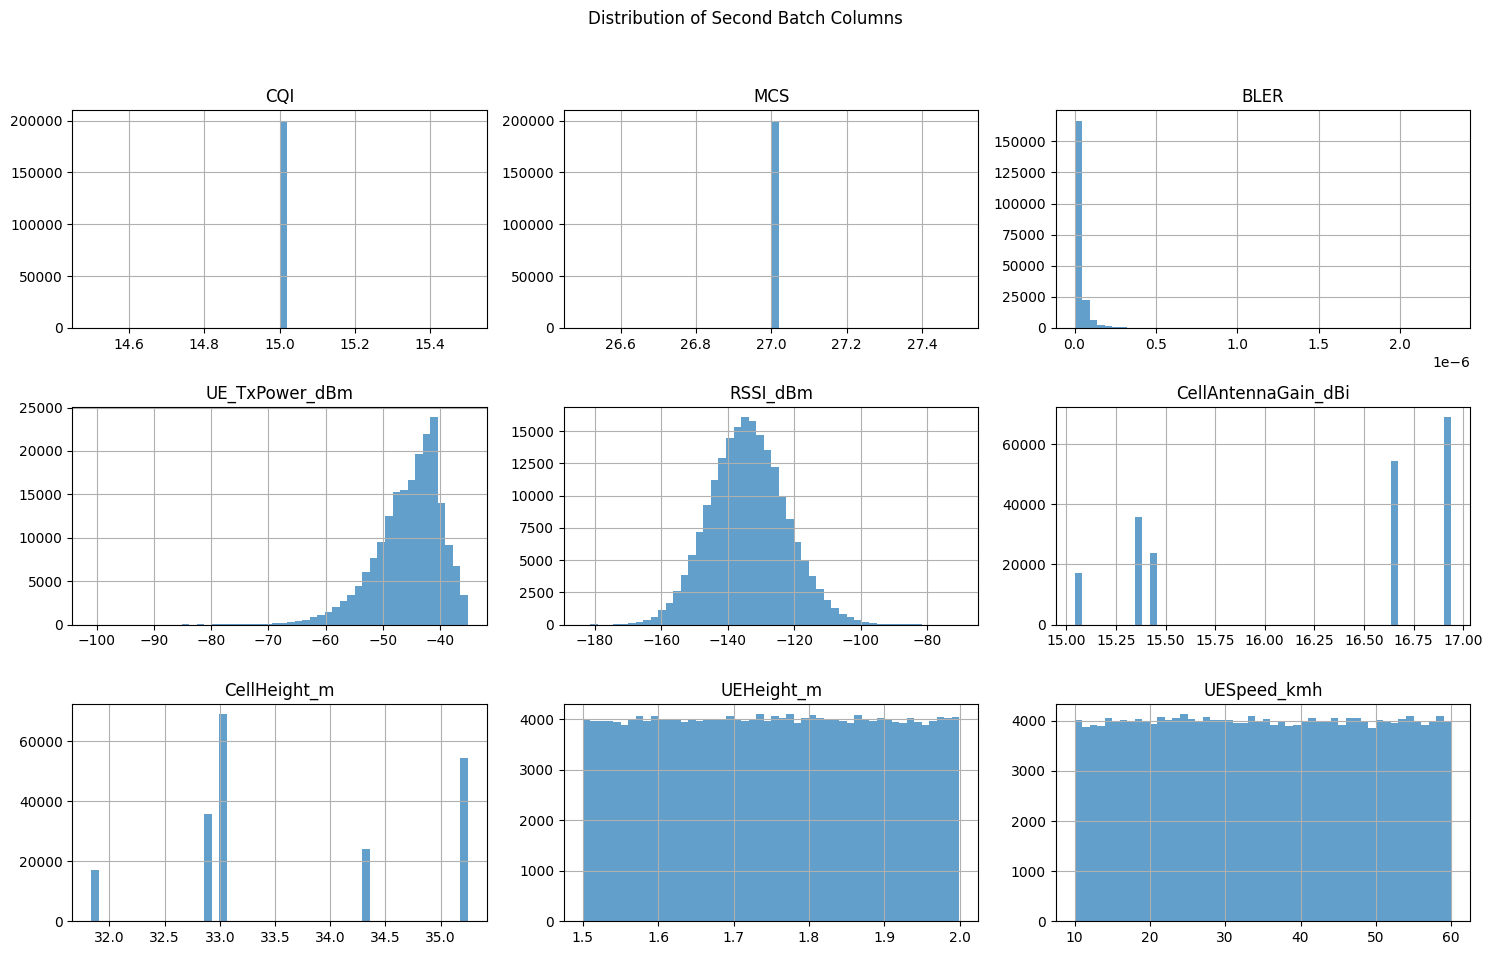

In [13]:
# Plotting the distribution of the second batch of columns
plt.figure(figsize=(15, 10))
df[second_batch_columns].hist(bins=50, figsize=(15, 10),
                                layout=(3, 3), alpha=0.7)
plt.suptitle('Distribution of Second Batch Columns')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

#### Check for outliers

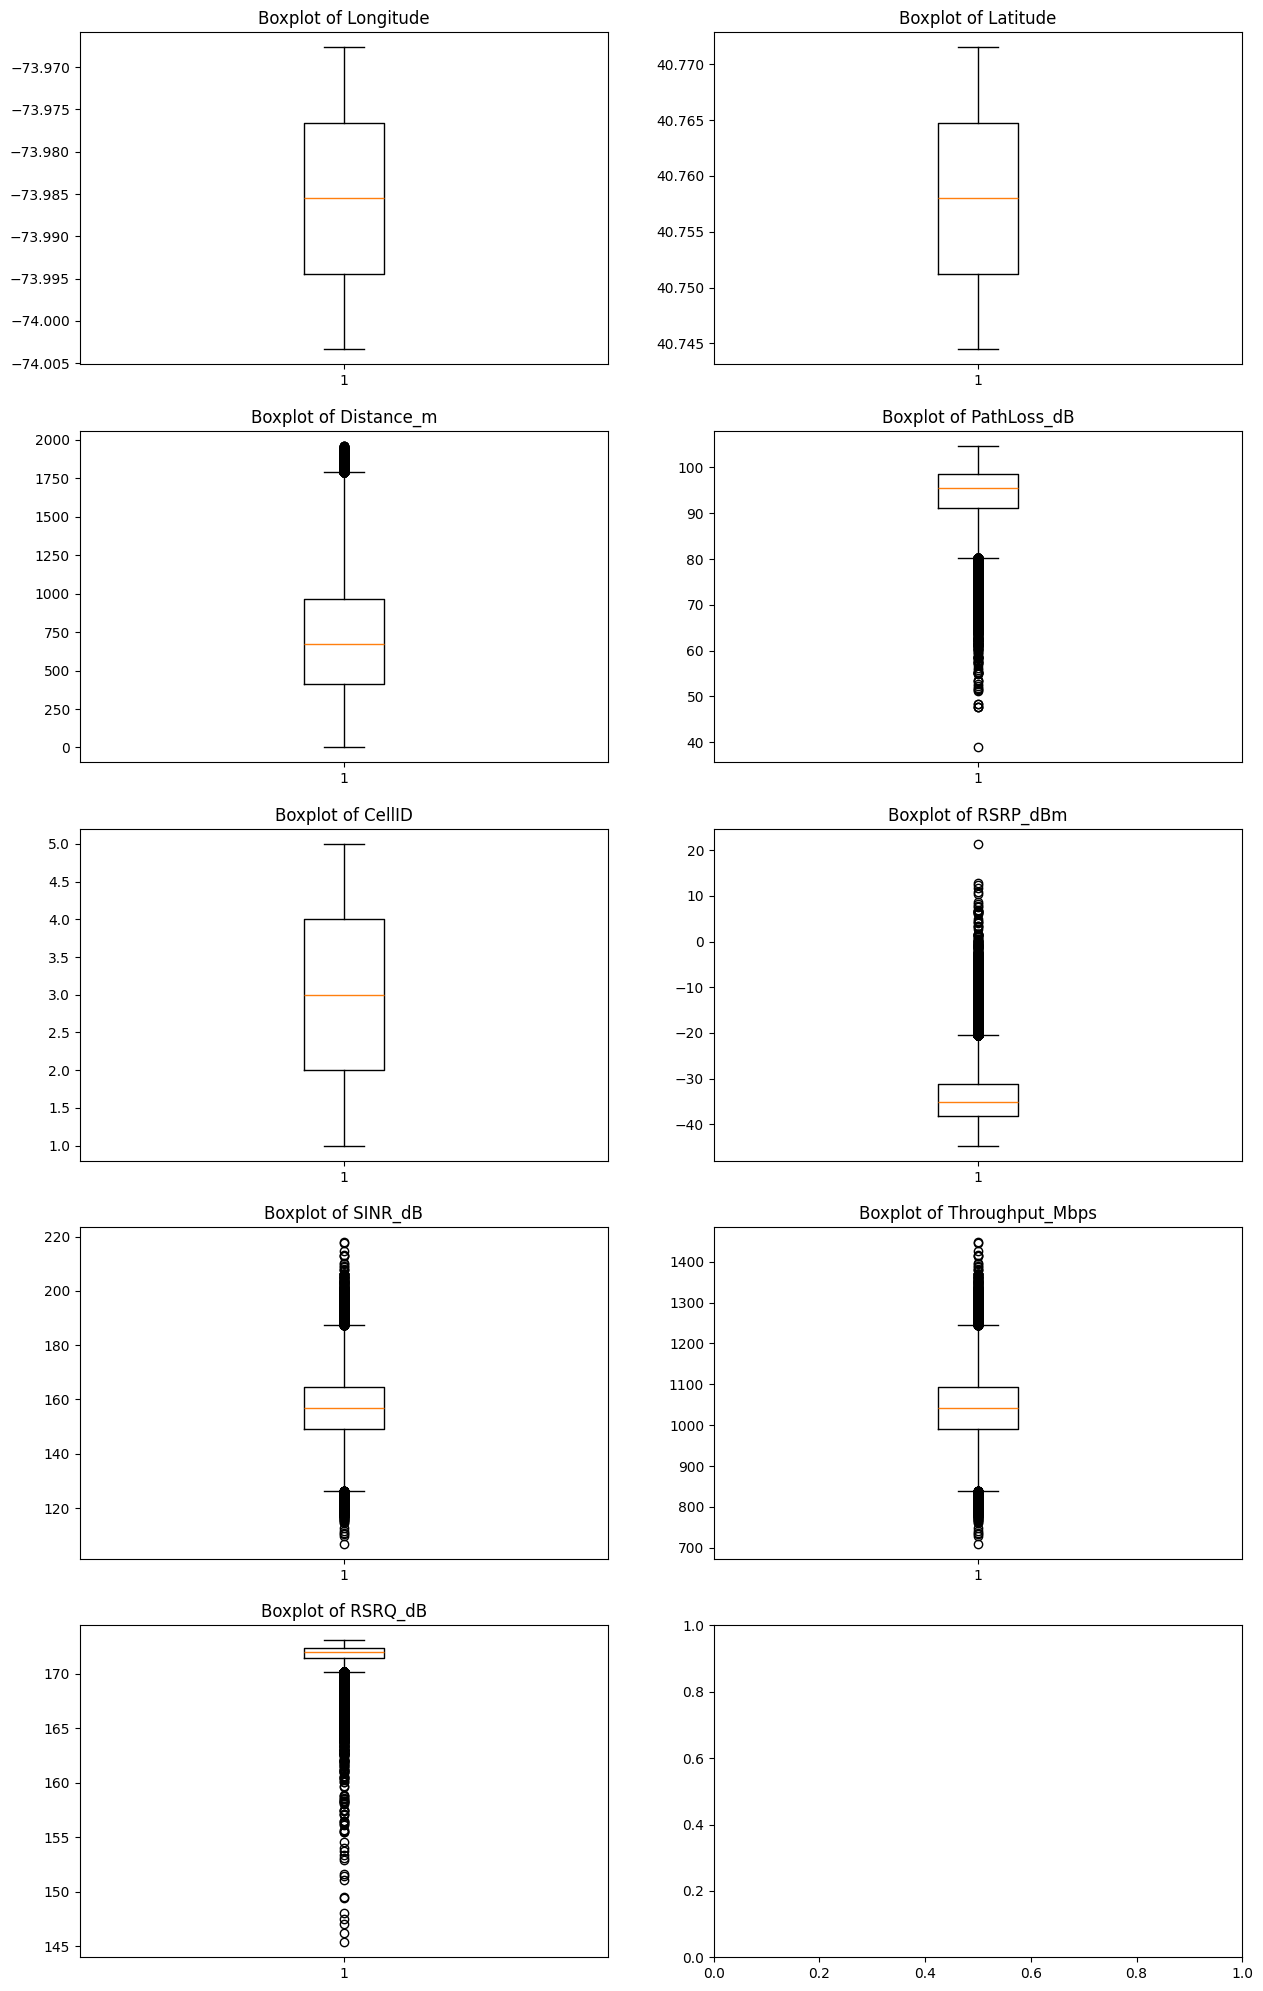

In [14]:

ncolumns = len(first_batch_columns)
nrows = (ncolumns + 1) // 2
plt.subplots(nrows=nrows, ncols=2, figsize=(15, 5 * nrows))
for i, column in enumerate(first_batch_columns):
    plt.subplot(nrows, 2, i + 1)
    plt.boxplot(df[column])
    plt.title(f'Boxplot of {column}')

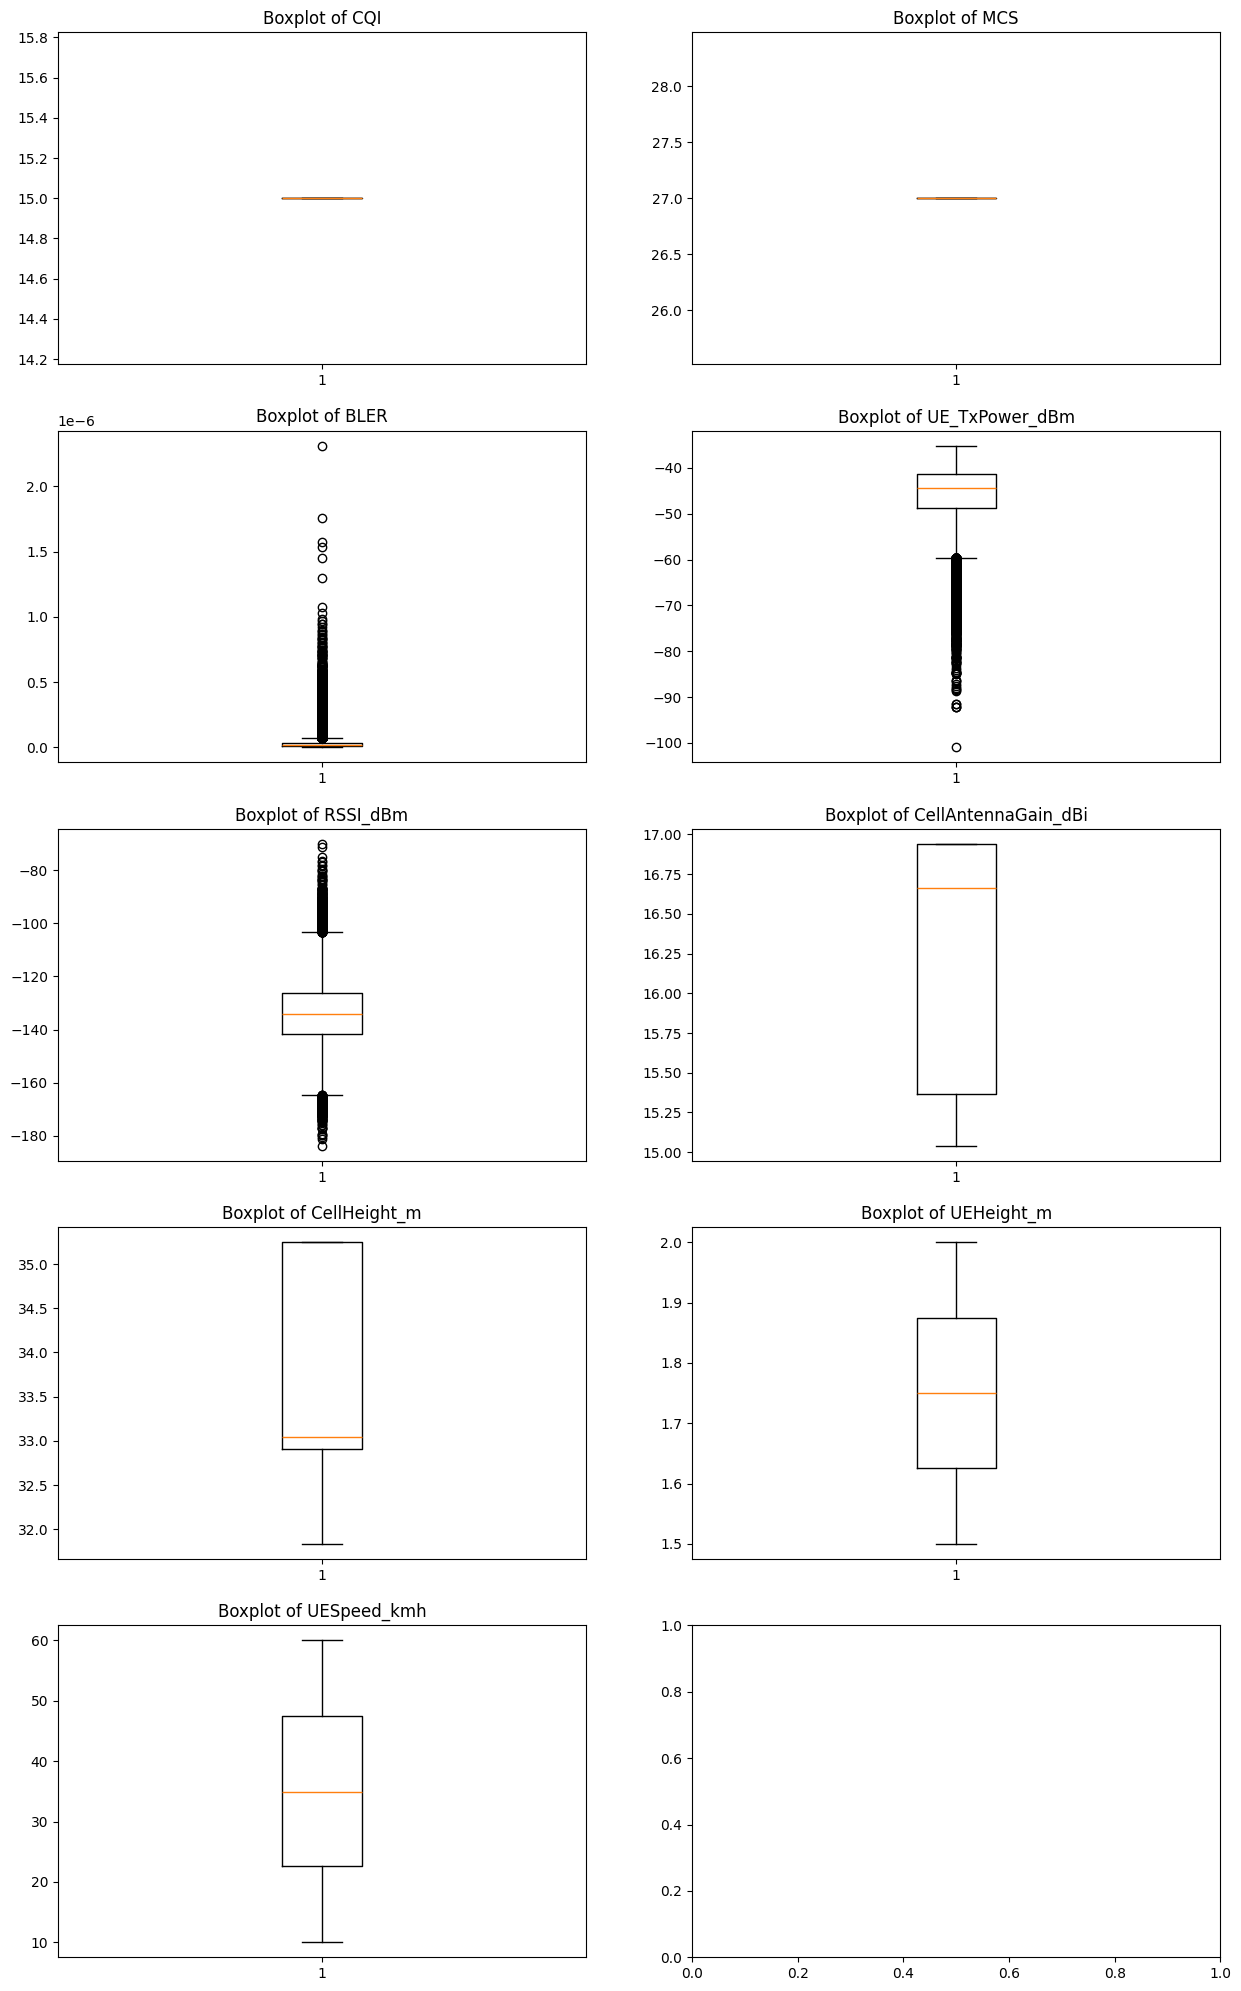

In [15]:
ncolumns = len(second_batch_columns)
nrows = (ncolumns + 1) // 2
plt.subplots(nrows=nrows, ncols=2, figsize=(15, 5 * nrows))
for i, column in enumerate(second_batch_columns):
    plt.subplot(nrows, 2, i + 1)
    plt.boxplot(df[column])
    plt.title(f'Boxplot of {column}')

#### Check and Remove Incosistent Values
## 📌 Data Inconsistency Rules and Examples

This table outlines expected value ranges for each feature in the drive test dataset and provides examples of inconsistencies that should be checked and addressed during data cleaning.

| **Feature**         | **Expected Range / Rule**              | **Inconsistency Example**                  |
|---------------------|----------------------------------------|--------------------------------------------|
| `Latitude`          | Between -90 and 90                     | Values > 90 or < -90                        |
| `Longitude`         | Between -180 and 180                   | Values > 180 or < -180                      |
| `RSRP_dBm`          | -140 to -44 dBm                        | Positive values or < -140                  |
| `RSRQ_db`           | Typically negative values (between -3dB - -20dB)|                                   |
| `SINR_dB`           | Greater than 0dB                        | Values < 20                       |
| `RSSI_dBm`          | Typically negative (often > -120 dBm) | Positive values                             |
| `CQI`               | Integers between 0 and 15              | Values > 15 or < 0                          |
| `MCS`               | Integers between 0 and 15              | Values > 15 or < 0                          |
| `Throughput_Mbps`   | ≥ 0                                    | Negative values                             |
| `UEHeight_m`        | Between 1.0 and 2.5 meters             | Values > 20 meters                          |
| `UESpeed_kmh`       | 0 to 200 km/h (realistic upper bound)  | Speeds > 300 km/h                           |

> ⚠️ **Note:** These rules are based on telecom engineering standards and domain knowledge of LTE/5G drive test metrics.


In [16]:
# Check info about RSRP_dBm
df["RSRP_dBm"].describe()

count    200000.000000
mean        -34.134395
std           5.629400
min         -44.679149
25%         -38.214327
50%         -35.165500
75%         -31.136791
max          21.380215
Name: RSRP_dBm, dtype: float64

In [17]:
# count rows with positive RSRP_dBm values
df[df["RSRP_dBm"]> 0].shape

(44, 18)

In [18]:
# Remove the positive RSRP_dBm values
df = df[df["RSRP_dBm"] <= 0]
df

,Latitude,Longitude,Distance_m,PathLoss_dB,CellID,RSRP_dBm,RSRQ_dB,SINR_dB,Throughput_Mbps,CQI,MCS,BLER,UE_TxPower_dBm,RSSI_dBm,CellAntennaGain_dBi,CellHeight_m,UEHeight_m,UESpeed_kmh
0,40.761023,-73.976731,117.745158,80.305019,5,-21.200108,169.798978,173.171611,1150.527275,15,27,3.014758e-09,-59.570839,-124.247888,15.363650,32.912291,1.578404,35.006782
1,40.748257,-73.988530,780.293211,96.731315,3,-35.402599,172.025949,153.424786,1019.332191,15,27,2.171932e-08,-43.144543,-132.906047,16.664885,35.247564,1.660524,20.351469
2,40.752382,-73.968726,254.393630,86.996283,1,-27.378540,170.909701,168.694687,1120.783236,15,27,4.717184e-09,-52.879575,-132.127831,15.041169,31.834045,1.789815,18.864764
3,40.754388,-73.987464,1059.720014,99.389981,5,-39.973001,172.553265,140.686947,934.703771,15,27,7.763249e-08,-40.485877,-129.309011,15.363650,32.912291,1.685947,40.281879
4,40.756813,-73.994663,939.036749,98.339810,3,-36.758789,172.189210,156.420352,1039.234307,15,27,1.609720e-08,-41.536048,-138.613992,16.664885,35.247564,1.885629,34.815708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,40.756964,-73.970811,286.936453,88.041873,1,-28.237791,171.043905,161.466728,1072.761713,15,27,9.718273e-09,-51.833986,-126.618373,15.041169,31.834045,1.923776,57.208642
199996,40.766762,-73.997982,1375.845460,101.657551,2,-40.030530,172.559511,156.536104,1040.003348,15,27,1.591195e-08,-38.218307,-145.273227,16.939820,33.042422,1.621588,31.248034
199997,40.766798,-73.984720,363.727998,90.101693,2,-29.419366,171.221931,173.399536,1152.041576,15,27,2.946822e-09,-49.774165,-140.914330,16.939820,33.042422,1.662731,11.930274
199998,40.753666,-73.974488,439.754875,91.750371,1,-33.251505,171.753711,142.345423,945.722459,15,27,6.576833e-08,-48.125487,-117.524495,15.041169,31.834045,1.500673,41.262722


#### Handle Inconsistensies in SINR_dB and SINR_dB

In [19]:
df["SINR_dB"].describe()

count    199956.000000
mean        156.875913
std          11.450021
min         106.748857
25%         149.095389
50%         156.676754
75%         164.399681
max         217.904112
Name: SINR_dB, dtype: float64

In [20]:
df["RSRQ_dB"].describe()

count    199956.000000
mean        171.794422
std           0.875920
min         145.372459
25%         171.468866
50%         171.996946
75%         172.357925
max         173.036647
Name: RSRQ_dB, dtype: float64

In [21]:
# Convert linear SINR and RSRQ to dB
df['SINR_dB'] = 10 * np.log10(df['SINR_dB'])
# Convert linear RSRQ to dB scale
df['RSRQ_dB'] = 10 * np.log10(df['RSRQ_dB'])

In [22]:
df["SINR_dB"].describe()

count    199956.000000
mean         21.943971
std           0.317690
min          20.283632
25%          21.734642
50%          21.950046
75%          22.159010
max          23.382654
Name: SINR_dB, dtype: float64

In [23]:
df["RSRQ_dB"].describe()

count    199956.000000
mean         22.350033
std           0.022351
min          21.624821
25%          22.341853
50%          22.355207
75%          22.364313
max          22.381381
Name: RSRQ_dB, dtype: float64

#### Scatter Plot to Visualise the Relationship Between Throughput and Features

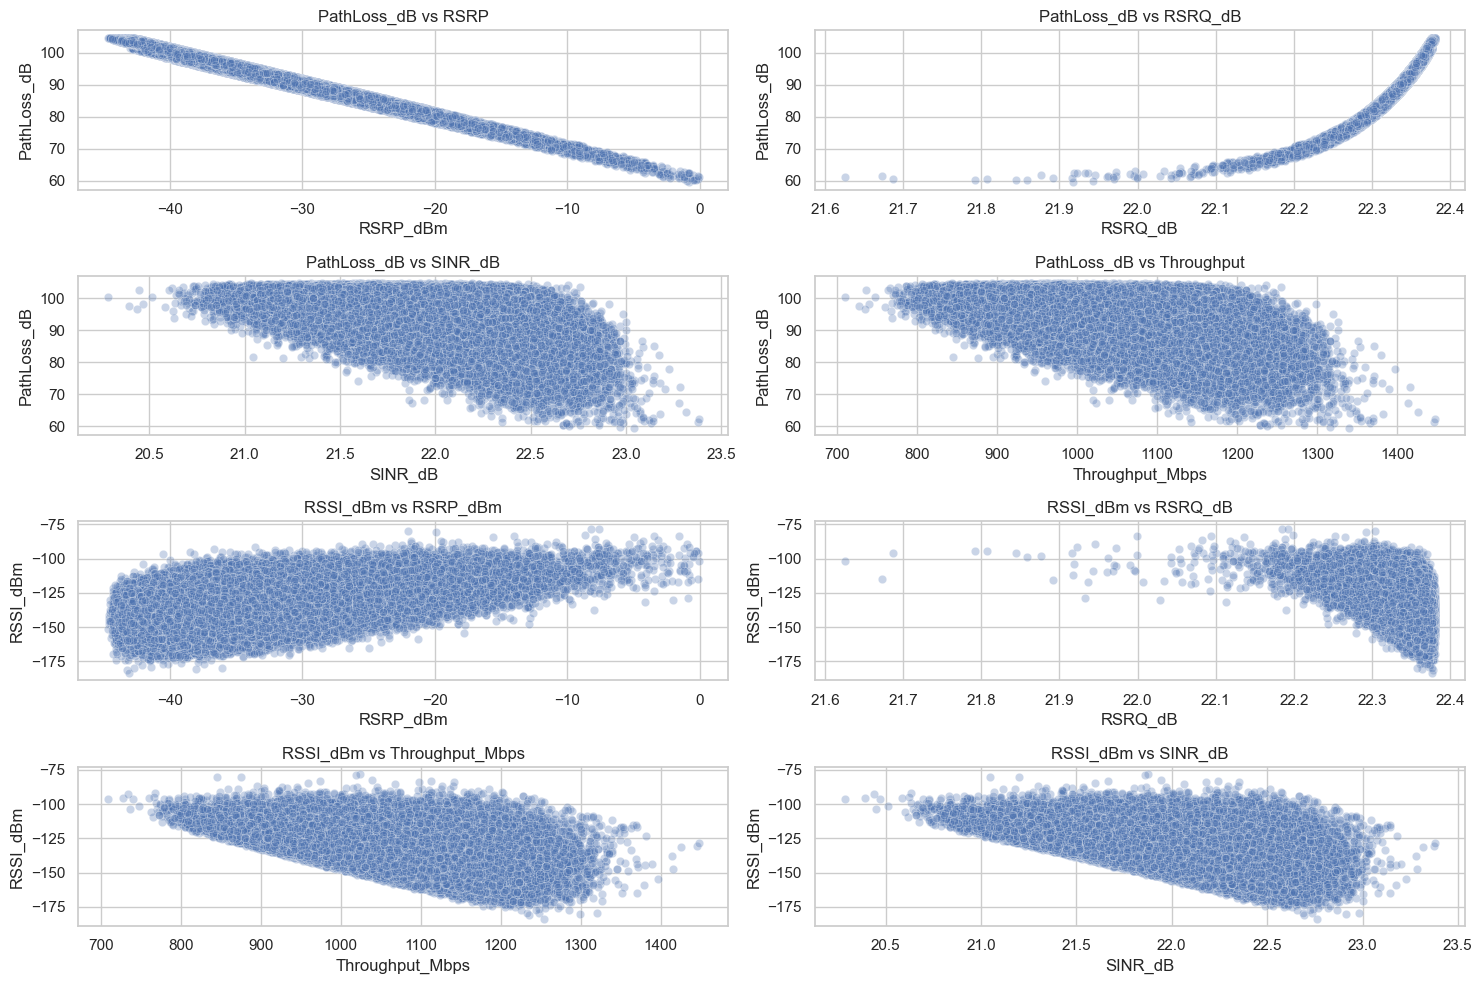

In [24]:
# set seaborn style
sns.set(style="whitegrid")

# create plots
plt.figure(figsize=(15, 10))

# Plotting the distribution of PathLoss_dB vrs RSRP
plt.subplot(4, 2, 1)
sns.scatterplot(data=df, x='RSRP_dBm', y='PathLoss_dB', alpha=0.3)
plt.title('PathLoss_dB vs RSRP')

# PathLoss_dB vs RSRQ
plt.subplot(4, 2, 2)
sns.scatterplot(x='RSRQ_dB', y='PathLoss_dB', data=df, alpha=0.3)
plt.title('PathLoss_dB vs RSRQ_dB')

# PathLoss_dB vs SINR
plt.subplot(4, 2, 3)
sns.scatterplot(x='SINR_dB', y='PathLoss_dB', data=df, alpha=0.3)
plt.title('PathLoss_dB vs SINR_dB')

# PathLoss_dB vs Throughput
plt.subplot(4, 2, 4)
sns.scatterplot(x='Throughput_Mbps', y='PathLoss_dB', data=df, alpha=0.3)
plt.title('PathLoss_dB vs Throughput')

# RSSI vs RSRP
plt.subplot(4, 2, 5)
sns.scatterplot(x='RSRP_dBm', y='RSSI_dBm', data=df, alpha=0.3)
plt.title('RSSI_dBm vs RSRP_dBm')

# RSSI vs RSRQ
plt.subplot(4, 2, 6)
sns.scatterplot(x='RSRQ_dB', y='RSSI_dBm', data=df, alpha=0.3)
plt.title('RSSI_dBm vs RSRQ_dB')

# RSSI vs Throughput_Mbps
plt.subplot(4, 2, 7)
sns.scatterplot(x='Throughput_Mbps', y='RSSI_dBm', data=df, alpha=0.3)
plt.title('RSSI_dBm vs Throughput_Mbps')

# RSSI vs SINR
plt.subplot(4, 2, 8)
sns.scatterplot(x='SINR_dB', y='RSSI_dBm', data=df, alpha=0.3)
plt.title('RSSI_dBm vs SINR_dB')

plt.tight_layout()
plt.show()

#### Correlation Matrix

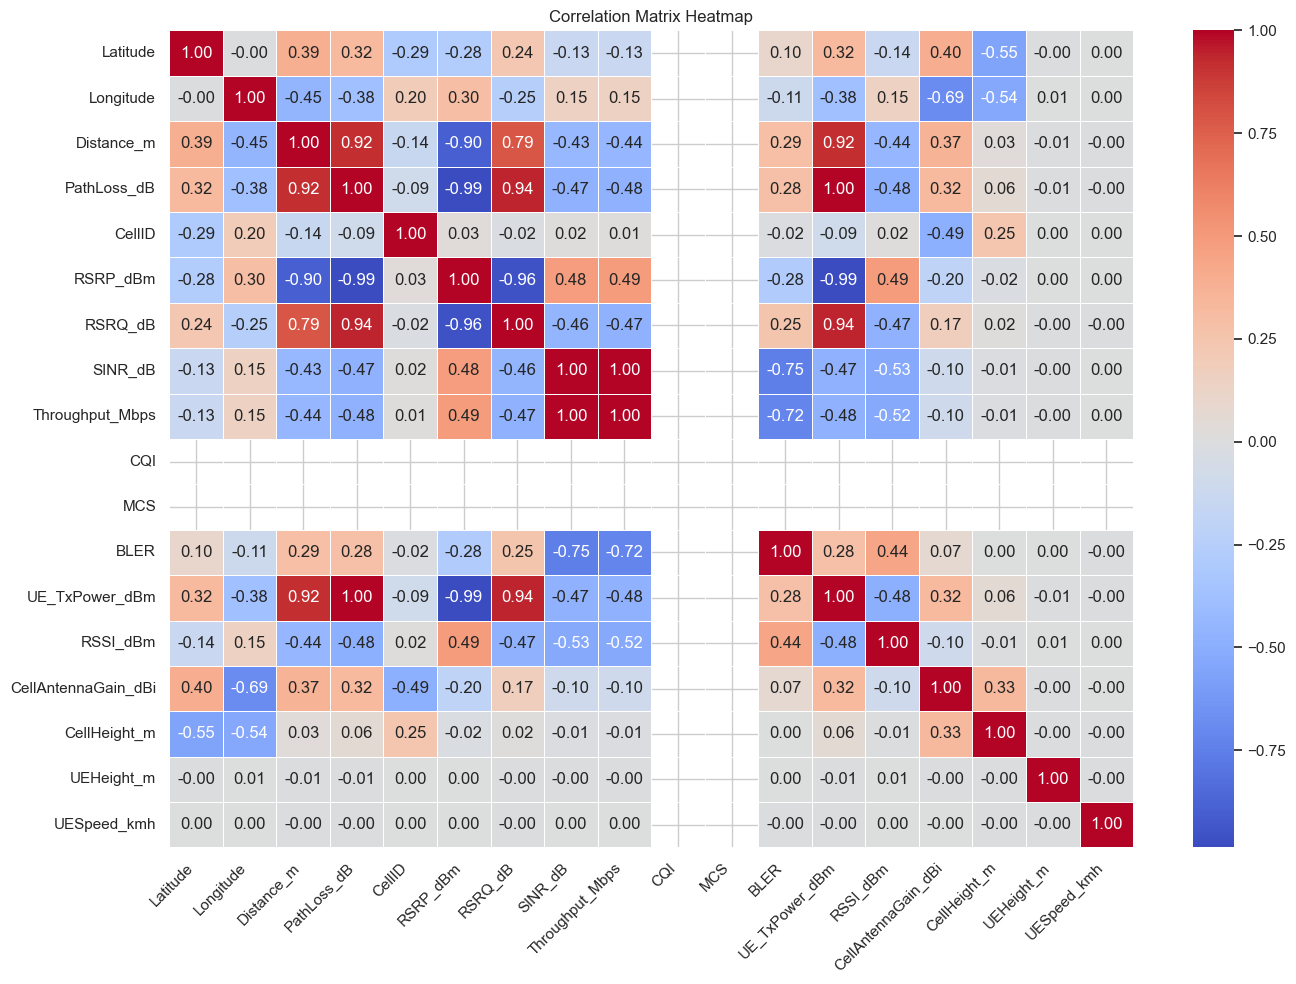

In [25]:
# Convert all columns to numeric where possible
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop columns with all NaN values)
df = df.dropna(axis=1, how='all')

# Compute the correlation matrix
corr_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Data Preparation

In [26]:
df.columns

Index(['Latitude', 'Longitude', 'Distance_m', 'PathLoss_dB', 'CellID',
       'RSRP_dBm', 'RSRQ_dB', 'SINR_dB', 'Throughput_Mbps', 'CQI', 'MCS',
       'BLER', 'UE_TxPower_dBm', 'RSSI_dBm', 'CellAntennaGain_dBi',
       'CellHeight_m', 'UEHeight_m', 'UESpeed_kmh'],
      dtype='object')

In [27]:
# Drop unnecessary columns based on corr-matrix
df = df.drop(columns=['CellID','CellHeight_m', 'CQI', 'MCS','UEHeight_m', 'UESpeed_kmh'])

In [28]:
df.head()

,Latitude,Longitude,Distance_m,PathLoss_dB,RSRP_dBm,RSRQ_dB,SINR_dB,Throughput_Mbps,BLER,UE_TxPower_dBm,RSSI_dBm,CellAntennaGain_dBi
0,40.761023,-73.976731,117.745158,80.305019,-21.200108,22.299351,22.384767,1150.527275,3.014758e-09,-59.570839,-124.247888,15.363650
1,40.748257,-73.988530,780.293211,96.731315,-35.402599,22.355940,21.858955,1019.332191,2.171932e-08,-43.144543,-132.906047,16.664885
2,40.752382,-73.968726,254.393630,86.996283,-27.378540,22.327667,22.271014,1120.783236,4.717184e-09,-52.879575,-132.127831,15.041169
3,40.754388,-73.987464,1059.720014,99.389981,-39.973001,22.369232,21.482538,934.703771,7.763249e-08,-40.485877,-129.309011,15.363650
4,40.756813,-73.994663,939.036749,98.339810,-36.758789,22.360059,21.942933,1039.234307,1.609720e-08,-41.536048,-138.613992,16.664885


In [29]:
# Define the features and target variables
X = df.drop(columns=['PathLoss_dB','RSSI_dBm'])
y = df[['PathLoss_dB','RSSI_dBm']]

##### Train-Test Split

In [30]:
# Train-test split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.3, random_state=42)

#### Split Data Into X and y


In [31]:
# print the shapes of the train and test sets
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")


X_train shape: (139969, 10), y_train shape: (139969, 2)
X_test shape: (59987, 10), y_test shape: (59987, 2)


#### Building the ML Pipeline

#### Scale the features using RobustScaler
- RobustScaler is used to scale features by removing the median and scaling the data according to the
- Interquartile range, which is robust to outliers.
- This is particularly useful when the dataset contains outliers, as it reduces their influence on them  



In [32]:
X_preprocessor = Pipeline([
    ('scaler', RobustScaler()),
])

y_preprocessor = Pipeline([
    ('scaler', RobustScaler()),
])

In [33]:
X_train_preprocesssed = X_preprocessor.fit_transform(X_train)
X_test_preprocessed = X_preprocessor.transform(X_test)

In [34]:
y_scaler = RobustScaler()
y_train_scaled = y_preprocessor.fit_transform(y_train)
y_test_scaled = y_preprocessor.transform(y_test)

#### Building The ML Model

In [35]:
# # instantiate the model
# multioutput_regressor = MultiOutputRegressor(SVR(kernel="rbf", C=100, gamma="scale"))


# # Fit the the model with the training data
# multioutput_regressor.fit(X_train_scaled,y_train_scaled)

In [36]:
# predicted_values = multioutput_regressor.predict(X_test_scaled)
# predicted_values

In [37]:
# # Inverse Transform
# inverse_predictions = y_scaler.inverse_transform(predicted_values)
# inverse_predictions

#### Evaluate the ML Model

In [38]:
# # Calculate the mean absolute error for my model
# mae = mean_absolute_error(y_test,inverse_predictions)

# # Calculate the mean squared error for my model
# mse = mean_squared_error(y_test,inverse_predictions)

# print("The mean absolute error of your model is: ", mae)
# print("The mean squared error of your model is: ", mse)


#### Building the Deep Learning Model

In [39]:
# Define model
def build_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=(input_shape,)),
        
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),

        layers.Dense(2)  # Output layer for PathLoss_dB, RSSI_dBm
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='mse', 
        metrics=['mae']
    )
    
    return model


#### Training the Deep Learning Model

In [40]:
model = build_model(input_shape=X_train_preprocesssed.shape[1])

# Optional: Early stopping to prevent overfitting
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train_preprocesssed, y_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 35s 8ms/step - loss: 0.2378 - mae: 0.3260 - val_loss: 0.0206 - val_mae: 0.0995
Epoch 2/100
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 0.0537 - mae: 0.1713 - val_loss: 0.0097 - val_mae: 0.0683
Epoch 3/100
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 0.0450 - mae: 0.1562 - val_loss: 0.0065 - val_mae: 0.0553
Epoch 4/100
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - loss: 0.0398 - mae: 0.1466 - val_loss: 0.0082 - val_mae: 0.0522
Epoch 5/100
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - loss: 0.0368 - mae: 0.1403 - val_loss: 0.0092 - val_mae: 0.0501
Epoch 6/100
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 0.0350 - mae: 0.1365 - val_loss: 0.0126 - val_mae: 0.0579
Epoch 7/100
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 34s 10ms/step - loss: 0.0334 - mae: 0.1327 - val_loss: 0.0086 - val_mae: 0.0505
Epoch 8/100
3500/3500 ━━━━━━━━━━━━━━━━━━━━ 33s 9ms/step - loss: 0.0323 - mae: 0.1302 - val_loss: 0.0107 - val_mae: 0.0519
Epoch 9/100
3500/3500 

#### Get the Model's Architecture

In [41]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,928 (554.41 KB)

 Trainable params: 47,010 (183.63 KB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 94,022 (367.28 KB)

#### Evaluate the Model

In [42]:
# Evaluate on test set
test_loss, test_mae = model.evaluate(X_test_preprocessed, y_test_scaled)
print(f"Test MAE: {test_mae:.4f}")

# Predict and inverse scale if needed
y_pred_scaled = model.predict(X_test_preprocessed)
y_pred = y_preprocessor.inverse_transform(y_pred_scaled)  


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0060 - mae: 0.0549
Test MAE: 0.0550
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step


In [43]:
y_pred

array([[ 103.02106 , -146.51558 ],
       [  97.953636, -133.13747 ],
       [ 100.88457 , -135.81194 ],
       ...,
       [  98.12799 , -146.22356 ],
       [  97.591125, -125.56848 ],
       [  98.83069 , -128.80699 ]], dtype=float32)

#### Visualize Loss Curve

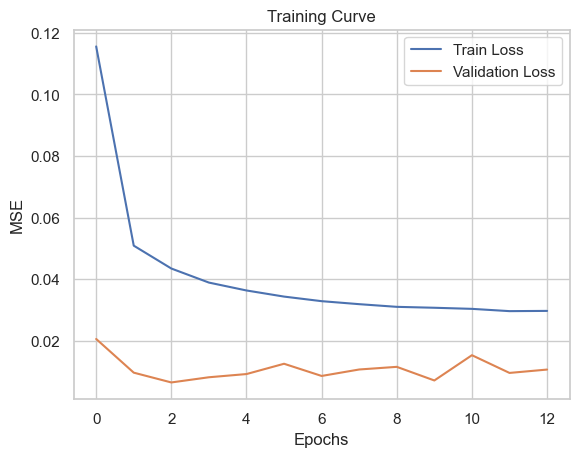

In [44]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("MSE")
plt.legend()
plt.title("Training Curve")
plt.grid(True)
plt.show()


#### Save the Deep Learning Model

In [45]:
model.save('drive_test_prediction.h5')

#### Persist the Preprocessor

In [46]:
# Save the preprocessor

model_components = {
    "scaler": y_scaler,
    "preprocessor": preprocessor
}

joblib.dump(model_components, 'model_components.joblib')

NameError: name 'preprocessor' is not defined

#### Load Saved Model

In [ ]:
saved_model = keras.models.load_model('drive_test_prediction.h5')



TypeError: Could not locate function 'mse'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'module': 'keras.metrics', 'class_name': 'function', 'config': 'mse', 'registered_name': 'mse'}

In [ ]:
# Make predictions on the test set
predictions = saved_model.predict(X_test_preprocessed)
predictions

1560/1560 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step


array([[ 1.1266745 ,  0.7758595 ,  0.02575091],
       [ 0.8719891 ,  0.01507507, -0.48022324],
       [-0.20576774, -0.01741935, -0.4955926 ],
       ...,
       [ 0.76688355,  0.7949825 ,  0.01449542],
       [-0.2115734 , -0.09226508, -1.0540035 ],
       [-0.5971368 ,  0.00680387, -0.25159496]], dtype=float32)

In [ ]:
inverse_predictions = y_scaler.inverse_transform(predictions)  
inverse_predictions

array([[ -69.339836  ,   -2.6896858 ,    5.1287546 ],
       [ -74.68823   ,  -11.819099  ,    2.5988839 ],
       [ -97.32112   ,  -12.209032  ,    2.522037  ],
       ...,
       [ -76.89545   ,   -2.4602098 ,    5.072477  ],
       [ -97.44304   ,  -13.107182  ,   -0.27001762],
       [-105.53987   ,  -11.918354  ,    3.7420251 ]], dtype=float32)